In [1]:
from opfython.models import SupervisedOPF

In [2]:
from testflows.combinatorics import Covering
from matplotlib.ticker import MaxNLocator
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
from sklearn import svm
import random
from sklearn.neighbors import KNeighborsClassifier
from numpy import inf
import time
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score
import umap

d:\Tesis\icafs\icafs\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df_cis = pd.read_csv('../data/cis_data.csv')
df_cacao = pd.read_csv(r'..\\data\\data_temp\\cacao.csv')
df_algarrobo = pd.read_csv(r'..\\data\\data_temp\\algarrobo.csv')
df_fruits_pures = pd.read_csv(r'../data/data_temp/MIR_Fruit_purees.csv')
df_fresh_meat = pd.read_csv(r'../data/data_temp/Fresh_meats.csv')
df_olive = pd.read_csv(r'../data/data_temp/Olive_Oils_Quadrum.csv')


df_x_cacao = df_cacao.iloc[:, 1:]
y_cacao = df_cacao.iloc[:, 0:1]
X_cacao = (df_x_cacao-df_x_cacao.min())/(df_x_cacao.max()-df_x_cacao.min())

algarrobo_x = df_algarrobo.loc[:, 'R':'REDVI']
y_algarrobo = df_algarrobo['Labels'].replace(to_replace=['N', 'P'], value=[0, 1])
X_algarrobo = (algarrobo_x-algarrobo_x.min())/(algarrobo_x.max()-algarrobo_x.min())

cis_x = df_cis[['X', 'Y', 'X10', 'Y10', 'X20', 'Y20', 'X30', 'Y30', 'X40', 'Y40']]
y_cis = df_cis[['Result']]
X_cis = (cis_x-cis_x.min())/(cis_x.max()-cis_x.min())



unique_names_berry = df_fruits_pures["label"].unique()
fruits_pures_x = df_fruits_pures.iloc[:,1:]
y_fruit_puree = df_fruits_pures.iloc[:,0:1].replace(to_replace=unique_names_berry, value =range(0,len(unique_names_berry)))
X_fruit_puree = (fruits_pures_x-fruits_pures_x.min())/(fruits_pures_x.max()-fruits_pures_x.min())


unique_names_meat = df_fresh_meat["meat"].unique()
meat_x = df_fresh_meat.iloc[:,4:]
y_meat = df_fresh_meat.iloc[:,0:1].replace(to_replace=unique_names_meat,value=range(0,len(unique_names_meat)))
X_meat =  (meat_x-meat_x.min())/(meat_x.max()-meat_x.min())

unique_names_olive = df_olive["Provenance"].unique()
olive_x = df_olive.iloc[:,3:]
y_olive = df_olive.iloc[:,2:3].replace(to_replace=unique_names_olive,value=range(0,len(unique_names_olive)))
X_olive =  (olive_x-olive_x.min())/(olive_x.max()-olive_x.min())


C:\Users\robma\AppData\Local\Temp\ipykernel_12500\940057218.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_algarrobo = df_algarrobo['Labels'].replace(to_replace=['N', 'P'], value=[0, 1])
C:\Users\robma\AppData\Local\Temp\ipykernel_12500\940057218.py:25: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_fruit_puree = df_fruits_pures.iloc[:,0:1].replace(to_replace=unique_names_berry, value =range(0,len(unique_names_berry)))
C:\Users\robma\AppData\Local\Temp\ipykernel_12500\940057218.py:31: FutureWarning: Downcasting behavior i

In [5]:
from sklearn.model_selection import KFold

def ICAFS(dataset_X, dataset_Y, strenght,max_iteartion,clasifier, print_logs=False):

  max_it = 1 
  score_list = []
  featur_list = []
  iter_list = []
  
  v_variable = [0, 1]
  best_f1_score = float('-inf')
  max_iteartion_aux =  max_iteartion
  best_data_set = dataset_X.columns.values.copy()

  initial_test_training(score_list,iter_list,featur_list,dataset_X,dataset_Y,clasifier)
  while max_iteartion_aux > 0:

      dict_parameters = {}
      partial_best_list = []
      partial_score = 0
      for colum_key in best_data_set:
          dict_parameters[colum_key] = v_variable
      random.shuffle(best_data_set)
      generate_covering_array = Covering(dict_parameters, strength=strenght)
      for test in generate_covering_array.array:
          list_attributes_to_consider = []

          check_for_all_cero = True
          for (test_key, test_value) in test.items():
              if test_value == 1:
                  check_for_all_cero = False
                  list_attributes_to_consider.append(test_key)

          if check_for_all_cero:
              continue  
          df_temp = dataset_X[list_attributes_to_consider]
          score = kfold_with_opf_in_icafs(clasifier,df_temp,dataset_Y)
          final_score = score.mean()

          if final_score >= partial_score :
              partial_score = final_score
              partial_best_list = list_attributes_to_consider
          clf_new = None
      best_data_set = partial_best_list.copy()
      best_f1_score = partial_score
      
      if print_logs:
        print(f"best f1 score= {best_f1_score}, iteration:{max_it}, numbers features selected ={ len(best_data_set)},best features selected={', '.join(best_data_set)}" )

      iter_list.append(max_it)
      aux_data_score = best_f1_score
      score_list.append(aux_data_score)
      max_iteartion_aux = max_iteartion_aux-1
      max_it = max_it +1
      featur_list.append(len(best_data_set))
  return iter_list,featur_list,score_list

def initial_test_training(score_list, iter_list, feature_list ,X,y,clasifier):
     X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(X.values, y.values.ravel(), test_size=0.20, random_state=42)
     clasifier.fit(X_train_temp, y_train_temp)
     y_pred = clasifier.predict(X_test_temp)
     score_list.append(f1_score(y_test_temp, y_pred,average='macro'))
     feature_list.append(X.shape[1])
     iter_list.append(0)

def kfold_with_opf_in_icafs(clasifier,x_data, y_data):
    
    scores = []
    kf = KFold(n_splits=5,shuffle=True, random_state =42)
    for i, (train_index, test_index) in enumerate(kf.split(x_data.values)):
   
        x_fold_train = x_data.values[train_index,:]
        y_fold_train = y_data.values[train_index]

        x_fold_test =  x_data.values[test_index,:]
        y_fold_test = y_data.values[test_index]
        
        clasifier.fit(x_fold_train, y_fold_train)
        y_pred_fold = clasifier.predict(x_fold_test)
        score = f1_score(y_fold_test, y_pred_fold,average='macro')
        scores.append(score)

    return np.asarray(scores, dtype=np.float32)

In [9]:
def  plot_results_for_covering_array(scores,feature,num_of_iterarion, path_to_save_image):
        color = 'tab:blue'
        res_scores = np.array(scores)
        res_features = np.array(feature)
        res_iter = np.array(num_of_iterarion)

        plt.figure(figsize=(11, 10))
        
        fig, ax1 = plt.subplots()
        barwidth = 0.4
        color = 'tab:red'
        ax1.set_xlabel('Iterations')
        ax1.set_ylabel('Number of features', color=color)
        #ax1.set_title("ICAFS Feature selection on the Cacao dataset")
        ax1.spines['top'].set_visible(False)
        ax1.bar(res_iter-0.2, res_features, color=color, width=barwidth)
        ax1.tick_params(axis='y', labelcolor=color,labelrotation=45)
        ax1.set_ylim(1,max(res_features)+3)
        ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
        
        for bar in ax1.patches:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width() / 2.0, height, f' {height}', fontsize=10,
                    ha='center', va='bottom', rotation=90)
            
        ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis
        color = 'tab:blue'
        ax2.set_ylabel('F1_score', color=color)
        ax2.bar(res_iter+0.2, res_scores, color=color, width=barwidth)
        ax2.tick_params(axis='y', labelcolor=color,labelrotation=45)
        ax2.set_ylim(min(res_scores)-0.001, max(res_scores)+0.001)

        fig.tight_layout()  # otherwise the right y-label is slightly clipped
       
        for bar in ax2.patches:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width() / 2.0, height, f' {height:.2f}', fontsize=10,
                    ha='center', va='bottom', rotation=90)

        #plt.title('ICAFS Feature selection for Cacao Dataset with OPF', y=-0.20)
        plt.gca().set_frame_on(False)
        plt.savefig(path_to_save_image)

2025-05-21 11:00:19,836 - opfython.models.supervised — INFO — Overriding class: OPF -> SupervisedOPF.
2025-05-21 11:00:19,837 - opfython.core.opf — INFO — Creating class: OPF.
2025-05-21 11:00:19,839 - opfython.core.opf — DEBUG — Distance: log_squared_euclidean | Pre-computed distance: False.
2025-05-21 11:00:19,840 - opfython.core.opf — INFO — Class created.
2025-05-21 11:00:19,842 - opfython.models.supervised — INFO — Class overrided.
2025-05-21 11:00:19,862 - opfython.models.supervised — INFO — Fitting classifier ...
2025-05-21 11:00:19,869 - opfython.models.supervised — DEBUG — Finding prototypes ...
2025-05-21 11:00:21,613 - opfython.models.supervised — DEBUG — Prototypes: [225, 287, 653, 313, 761, 740, 366, 262, 145, 25, 285, 752, 178, 578, 515, 182, 695, 549, 123, 563, 341, 647, 325, 597, 167, 632, 37, 408, 711, 63, 45, 656, 658, 121, 163, 521, 421, 388, 109, 363, 713, 791, 483, 668, 395, 208, 156, 72, 558, 725, 398, 719, 619, 65, 299, 750, 70, 250, 426, 256, 43, 3, 624, 358, 19

<Figure size 1100x1000 with 0 Axes>

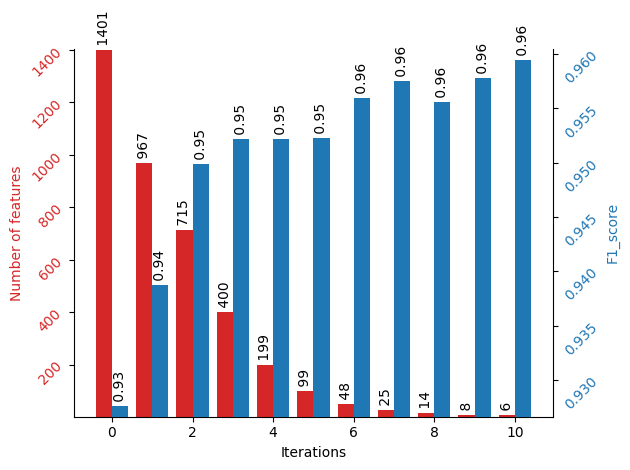

In [23]:
start_time = time.time()
algorithm = SupervisedOPF(distance="log_squared_euclidean", pre_computed_distance=None)
iterations ,feature,score  = ICAFS(X_cacao,y_cacao,2,10,algorithm,True )
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\cacao_opf_icafs.png')

2025-05-21 10:50:39,438 - opfython.models.supervised — INFO — Overriding class: OPF -> SupervisedOPF.
2025-05-21 10:50:39,439 - opfython.core.opf — INFO — Creating class: OPF.
2025-05-21 10:50:39,441 - opfython.core.opf — DEBUG — Distance: log_squared_euclidean | Pre-computed distance: False.
2025-05-21 10:50:39,442 - opfython.core.opf — INFO — Class created.
2025-05-21 10:50:39,443 - opfython.models.supervised — INFO — Class overrided.
2025-05-21 10:50:39,446 - opfython.models.supervised — INFO — Fitting classifier ...
2025-05-21 10:50:39,452 - opfython.models.supervised — DEBUG — Finding prototypes ...
2025-05-21 10:50:39,890 - opfython.models.supervised — DEBUG — Prototypes: [638, 406, 206, 164, 596, 464, 188, 265, 504, 521, 195, 729, 320, 149, 395, 28, 261, 38, 256, 266, 632, 69, 359, 517, 51, 170, 644, 444, 426, 383, 696, 686, 693, 567, 424, 319, 397, 507, 85, 510, 654, 461, 791, 668, 289, 416, 605, 641, 457, 664, 280, 427, 283, 617, 220, 4, 75, 328, 749, 59, 401, 734, 493, 481, 3

<Figure size 1100x1000 with 0 Axes>

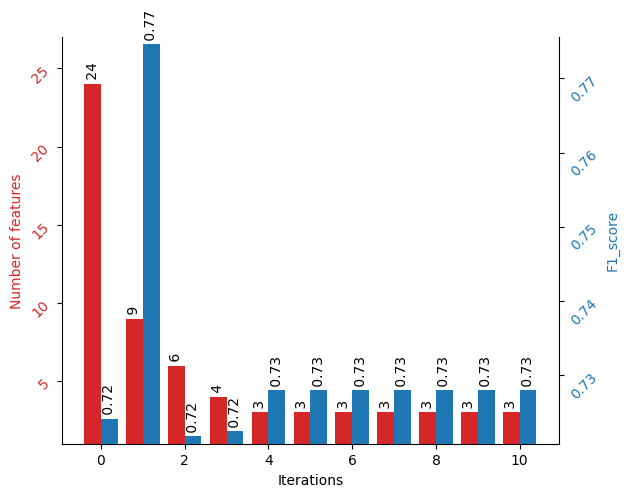

In [22]:
start_time = time.time()
algorithm = SupervisedOPF(distance="log_squared_euclidean", pre_computed_distance=None)
iterations ,feature,score = ICAFS(X_algarrobo,y_algarrobo,2,10,algorithm,True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\algarrobo_opf_icafs.png')

In [13]:
start_time = time.time()
algorithm = SupervisedOPF(distance="log_squared_euclidean", pre_computed_distance=None)
iterations ,feature,score = ICAFS(X_cis,y_cis,2,10,algorithm,True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'./output_images/cis_opf_icafs.png')

2025-05-22 22:17:28,815 - opfython.models.supervised — INFO — Overriding class: OPF -> SupervisedOPF.
2025-05-22 22:17:28,816 - opfython.core.opf — INFO — Creating class: OPF.
2025-05-22 22:17:28,818 - opfython.core.opf — DEBUG — Distance: log_squared_euclidean | Pre-computed distance: False.
2025-05-22 22:17:28,819 - opfython.core.opf — INFO — Class created.
2025-05-22 22:17:28,821 - opfython.models.supervised — INFO — Class overrided.
2025-05-22 22:17:28,826 - opfython.models.supervised — INFO — Fitting classifier ...
2025-05-22 22:17:28,885 - opfython.models.supervised — DEBUG — Finding prototypes ...


KeyboardInterrupt: 

2025-05-22 21:35:01,145 - opfython.models.supervised — INFO — Overriding class: OPF -> SupervisedOPF.
2025-05-22 21:35:01,147 - opfython.core.opf — INFO — Creating class: OPF.
2025-05-22 21:35:01,148 - opfython.core.opf — DEBUG — Distance: log_squared_euclidean | Pre-computed distance: False.
2025-05-22 21:35:01,150 - opfython.core.opf — INFO — Class created.
2025-05-22 21:35:01,151 - opfython.models.supervised — INFO — Class overrided.
2025-05-22 21:35:01,156 - opfython.models.supervised — INFO — Fitting classifier ...
2025-05-22 21:35:01,166 - opfython.models.supervised — DEBUG — Finding prototypes ...
2025-05-22 21:35:01,803 - opfython.models.supervised — DEBUG — Prototypes: [15, 335, 195, 188, 588, 629, 125, 658, 423, 122, 107, 482, 690, 302, 563, 745, 42, 642, 262, 589, 497, 610, 474, 628, 231, 300, 753, 472, 677, 581, 683, 159, 304, 93, 694, 506, 572, 307, 40, 727, 756, 244, 336, 255, 725, 273, 285, 114, 389, 25, 582, 301, 429, 452, 170, 681, 393, 540, 358, 23, 518, 465, 13].
202

<Figure size 1100x1000 with 0 Axes>

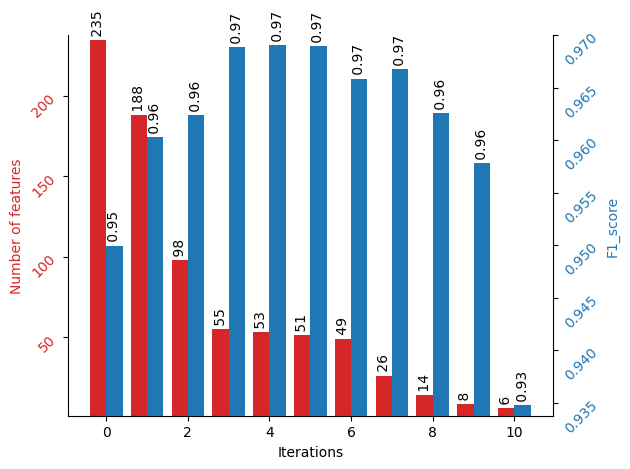

In [12]:
start_time = time.time()
algorithm = SupervisedOPF(distance="log_squared_euclidean", pre_computed_distance=None)
iterations ,feature,score = ICAFS(X_fruit_puree,y_fruit_puree,2,10,algorithm,True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'./output_images/fruit_puree_opf_icafs.png')

2025-05-22 22:21:30,292 - opfython.models.supervised — INFO — Overriding class: OPF -> SupervisedOPF.
2025-05-22 22:21:30,293 - opfython.core.opf — INFO — Creating class: OPF.
2025-05-22 22:21:30,295 - opfython.core.opf — DEBUG — Distance: log_squared_euclidean | Pre-computed distance: False.
2025-05-22 22:21:30,296 - opfython.core.opf — INFO — Class created.
2025-05-22 22:21:30,297 - opfython.models.supervised — INFO — Class overrided.
2025-05-22 22:21:30,300 - opfython.models.supervised — INFO — Fitting classifier ...
2025-05-22 22:21:30,302 - opfython.models.supervised — DEBUG — Finding prototypes ...
2025-05-22 22:21:30,321 - opfython.models.supervised — DEBUG — Prototypes: [9, 34, 77, 31, 58, 17, 92, 43, 71, 6].
2025-05-22 22:21:30,354 - opfython.models.supervised — INFO — Classifier has been fitted.
2025-05-22 22:21:30,355 - opfython.models.supervised — INFO — Training time: 0.052141666412353516 seconds.
2025-05-22 22:21:30,356 - opfython.models.supervised — INFO — Predicting dat

<Figure size 1100x1000 with 0 Axes>

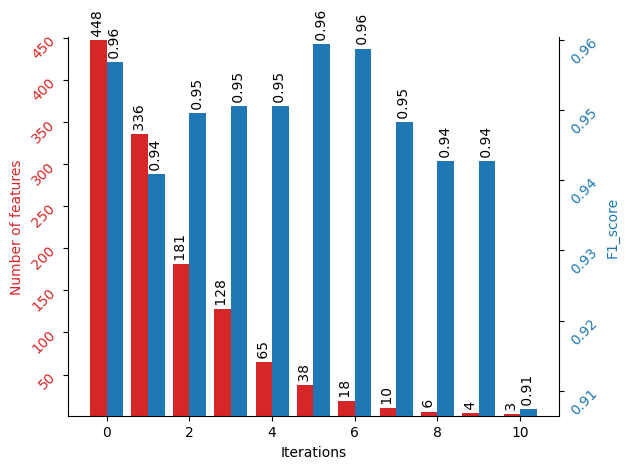

In [15]:
start_time = time.time()
algorithm = SupervisedOPF(distance="log_squared_euclidean", pre_computed_distance=None)
iterations ,feature,score = ICAFS(X_meat,y_meat,2,10,algorithm,True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'./output_images/meat_opf_icafs.png')

2025-05-22 22:24:16,935 - opfython.models.supervised — INFO — Overriding class: OPF -> SupervisedOPF.
2025-05-22 22:24:16,936 - opfython.core.opf — INFO — Creating class: OPF.
2025-05-22 22:24:16,938 - opfython.core.opf — DEBUG — Distance: log_squared_euclidean | Pre-computed distance: False.
2025-05-22 22:24:16,940 - opfython.core.opf — INFO — Class created.
2025-05-22 22:24:16,941 - opfython.models.supervised — INFO — Class overrided.
2025-05-22 22:24:16,945 - opfython.models.supervised — INFO — Fitting classifier ...
2025-05-22 22:24:16,947 - opfython.models.supervised — DEBUG — Finding prototypes ...
2025-05-22 22:24:16,969 - opfython.models.supervised — DEBUG — Prototypes: [87, 88, 42, 16, 19, 15, 25, 47, 13, 84, 24, 56, 18, 90, 69, 52, 4, 92, 70, 78].
2025-05-22 22:24:17,000 - opfython.models.supervised — INFO — Classifier has been fitted.
2025-05-22 22:24:17,001 - opfython.models.supervised — INFO — Training time: 0.053331613540649414 seconds.
2025-05-22 22:24:17,003 - opfython.

<Figure size 1100x1000 with 0 Axes>

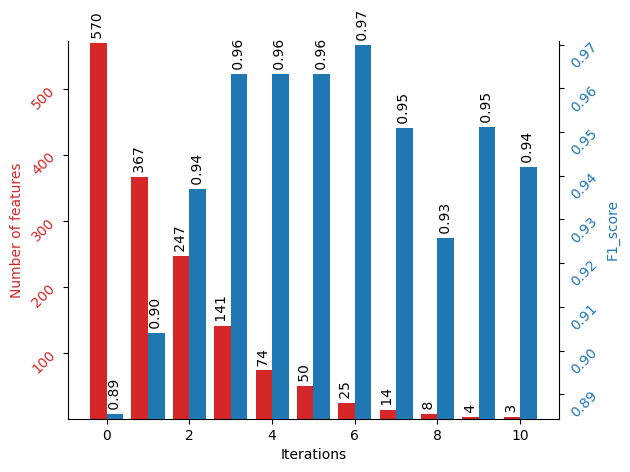

In [16]:
start_time = time.time()
algorithm = SupervisedOPF(distance="log_squared_euclidean", pre_computed_distance=None)
iterations ,feature,score = ICAFS(X_olive,y_olive,2,10,algorithm,True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'./output_images/olive_opf_icafs.png')